# Simplified Robust Pricing: Exact Martingale Optimal Transport

## Problem specification

| Element | Specification |
|---------|---------------|
| $\mu_1$ (marginal of $S_1$) | Uniform on $[1, 3]$ |
| $\mu_2$ (marginal of $S_2$) | Uniform on $[0, 4]$ |
| Payoff $G(S_1, S_2)$ | $abs(S_1 - S_2)$ |
| Martingale constraint | **Exact** ($\varepsilon = 0$): $\mathbb{E}[S_2 \mid S_1] = S_1$ |

We solve the upper-price MOT problem:
$$P(\mu_1, \mu_2) = \sup_{\mathbb{P} \in \mathcal{M}(\mu_1,\mu_2)} \mathbb{E}^{\mathbb{P}}[|S_1 - S_2|]$$

where $\mathcal{M}(\mu_1, \mu_2)$ is the set of martingale couplings with the given marginals.

### Feasibility — convex order check (Strassen's theorem)
A martingale coupling exists iff $\mu_1 \preceq_{cx} \mu_2$:
- $\mathbb{E}[S_1] = 2 = \mathbb{E}[S_2]$ &nbsp; ✓ (means match)
- $\operatorname{Var}(S_1) = \tfrac{1}{3} \leq \tfrac{4}{3} = \operatorname{Var}(S_2)$ &nbsp; ✓ ($\mu_2$ is more dispersed)

The problem is feasible.

## 1. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.integrate import dblquad

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})
print("Ready.")

Ready.


## 2. Discretize the Uniform Marginals

We place $n$ equally-spaced atoms (midpoints of equal sub-intervals) on each support,
each carrying weight $1/n$.

In [3]:
def make_uniform_grid(a, b, n):
    """
    Return n midpoint atoms on (a, b) and uniform weights 1/n.
    Midpoints ensure the empirical mean is exactly (a+b)/2.
    """
    edges = np.linspace(a, b, n + 1)
    atoms = 0.5 * (edges[:-1] + edges[1:])
    weights = np.ones(n) / n
    return atoms, weights


n = 50   # grid size — increase for higher accuracy

x_atoms, alpha = make_uniform_grid(1, 3, n)   # S1 ~ Uniform[1, 3]
y_atoms, beta  = make_uniform_grid(0, 4, n)   # S2 ~ Uniform[0, 4]

E_S1 = (x_atoms * alpha).sum()
E_S2 = (y_atoms * beta).sum()
Var_S1 = (x_atoms**2 * alpha).sum() - E_S1**2
Var_S2 = (y_atoms**2 * beta).sum()  - E_S2**2

print(f"Grid size  n = {n}")
print(f"E[S1] = {E_S1:.6f}   (exact: 2.000000)")
print(f"E[S2] = {E_S2:.6f}   (exact: 2.000000)")
print(f"Var[S1] = {Var_S1:.6f}  (exact: {4/12:.6f})")
print(f"Var[S2] = {Var_S2:.6f}  (exact: {16/12:.6f})")

Grid size  n = 50
E[S1] = 2.000000   (exact: 2.000000)
E[S2] = 2.000000   (exact: 2.000000)
Var[S1] = 0.333200  (exact: 0.333333)
Var[S2] = 1.332800  (exact: 1.333333)


## 3. Build and Solve the LP

Variables: $p_{ij} \geq 0$ for $i,j = 1,\ldots,n$.

$$\max_{p \geq 0} \sum_{i,j} p_{ij} |x_i - y_j|$$

subject to:
- $\sum_j p_{ij} = \alpha_i$ for all $i$ &nbsp; (marginal of $S_1$)
- $\sum_i p_{ij} = \beta_j$ for all $j$ &nbsp; (marginal of $S_2$)
- $\sum_j p_{ij} y_j = \alpha_i x_i$ for all $i$ &nbsp; (**exact** martingale, $\varepsilon=0$)

In [4]:
def build_and_solve_MOT(x_atoms, alpha, y_atoms, beta, payoff_fn,
                         minimise=False):
    """
    Build the exact-martingale (eps=0) MOT LP and solve it.

    Parameters
    ----------
    minimise : bool
        If True, compute the lower price bound (inf E[G]).

    Returns
    -------
    value  : float         optimal MOT value
    P_opt  : (m1, m2) array  optimal transport plan
    G      : (m1, m2) array  payoff matrix
    """
    m1, m2 = len(x_atoms), len(y_atoms)
    D = m1 * m2

    # Payoff matrix
    X, Y = np.meshgrid(x_atoms, y_atoms, indexing='ij')  # (m1, m2)
    G = payoff_fn(X, Y)
    sign = 1 if minimise else -1
    c = sign * G.ravel()   # linprog minimises

    # Equality constraints: row marginals + col marginals + exact martingale
    n_eq = m1 + m2 + m1
    A_eq = np.zeros((n_eq, D))
    b_eq = np.zeros(n_eq)
    ptr = 0

    # Row marginals: sum_j p_ij = alpha_i
    for i in range(m1):
        A_eq[ptr, i*m2:(i+1)*m2] = 1.0
        b_eq[ptr] = alpha[i]
        ptr += 1

    # Column marginals: sum_i p_ij = beta_j
    for j in range(m2):
        A_eq[ptr, j::m2] = 1.0
        b_eq[ptr] = beta[j]
        ptr += 1

    # Exact martingale: sum_j p_ij * y_j = alpha_i * x_i
    for i in range(m1):
        A_eq[ptr, i*m2:(i+1)*m2] = y_atoms
        b_eq[ptr] = alpha[i] * x_atoms[i]
        ptr += 1

    result = linprog(
        c,
        A_eq=A_eq, b_eq=b_eq,
        bounds=[(0, None)] * D,
        method='highs'
    )

    if result.status != 0:
        raise RuntimeError(f"LP failed: {result.message}")

    # linprog minimises c·p.
    # Maximise case: c = -G  =>  result.fun = -max(G·p)  =>  value = -result.fun
    # Minimise case: c =  G  =>  result.fun =  min(G·p)  =>  value =  result.fun
    value = result.fun if minimise else -result.fun
    P_opt = result.x.reshape(m1, m2)
    return value, P_opt, G


# Solve upper bound
payoff_abs_diff = lambda s1, s2: np.abs(s1 - s2)

MOT_upper, P_upper, G_mat = build_and_solve_MOT(
    x_atoms, alpha, y_atoms, beta, payoff_abs_diff
)

# Diagnostics
marg1_err = np.max(np.abs(P_upper.sum(axis=1) - alpha))
marg2_err = np.max(np.abs(P_upper.sum(axis=0) - beta))
mart_err  = np.max(np.abs(
    np.array([(P_upper[i] * y_atoms).sum() - alpha[i] * x_atoms[i]
              for i in range(n)])
))

print("━━ Solution (upper bound) ━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  sup E[|S1-S2|]  =  {MOT_upper:.6f}")
print(f"\n━━ Constraint satisfaction ━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Max S1 marginal error :  {marg1_err:.2e}")
print(f"  Max S2 marginal error :  {marg2_err:.2e}")
print(f"  Max martingale error  :  {mart_err:.2e}  (target: 0)")
print(f"  All p_ij >= 0         :  {(P_upper >= -1e-10).all()}")

━━ Solution (upper bound) ━━━━━━━━━━━━━━━━━━━━━━━━━━━
  sup E[|S1-S2|]  =  0.999600

━━ Constraint satisfaction ━━━━━━━━━━━━━━━━━━━━━━━━━━
  Max S1 marginal error :  2.78e-17
  Max S2 marginal error :  2.43e-17
  Max martingale error  :  4.16e-17  (target: 0)
  All p_ij >= 0         :  True


## 4. Benchmarks

In [5]:
# Classical OT upper bound: comonotone coupling (no martingale)
u = np.linspace(0, 1, 50000)
F1_inv = 1 + 2*u          # quantile of U[1,3]
F2_inv = 4*u              # quantile of U[0,4]
ot_upper = np.trapz(np.abs(F1_inv - F2_inv), u)

# Classical OT lower bound: anti-monotone coupling
ot_lower_nm = np.trapz(np.abs(F1_inv - (4 - 4*u)), u)

# Independent coupling
indep, _ = dblquad(
    lambda y, x: abs(x - y) * 0.5 * 0.25,
    1, 3, 0, 4
)

# MOT lower bound
MOT_lower, P_lower, _ = build_and_solve_MOT(
    x_atoms, alpha, y_atoms, beta, payoff_abs_diff, minimise=True
)

print("━━ Comparison of couplings ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  OT max (comonotone, no martingale)   =  {ot_upper:.6f}")
print(f"  MOT upper bound  (sup, with martg.)  =  {MOT_upper:.6f}  <-- main result")
print(f"  Independent coupling                 =  {indep:.6f}")
print(f"  MOT lower bound  (inf, with martg.)  =  {MOT_lower:.6f}")
print(f"  OT min (anti-monotone, no martg.)    =  {ot_lower_nm:.6f}")
print()
print(f"  Robust price interval: [{MOT_lower:.4f},  {MOT_upper:.4f}]")
print(f"  Width: {MOT_upper - MOT_lower:.4f}")
print(f"  Martingale constraint costs: {ot_upper - MOT_upper:.4f} vs unconstrained OT max")

━━ Comparison of couplings ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OT max (comonotone, no martingale)   =  0.500000
  MOT upper bound  (sup, with martg.)  =  0.999600  <-- main result
  Independent coupling                 =  1.083333
  MOT lower bound  (inf, with martg.)  =  0.598799
  OT min (anti-monotone, no martg.)    =  1.500000

  Robust price interval: [0.5988,  0.9996]
  Width: 0.4008
  Martingale constraint costs: -0.4996 vs unconstrained OT max


C:\Users\123\AppData\Local\Temp\ipykernel_25072\1198832113.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ot_upper = np.trapz(np.abs(F1_inv - F2_inv), u)
C:\Users\123\AppData\Local\Temp\ipykernel_25072\1198832113.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ot_lower_nm = np.trapz(np.abs(F1_inv - (4 - 4*u)), u)


## 5. Visualise the Optimal Transport Plan

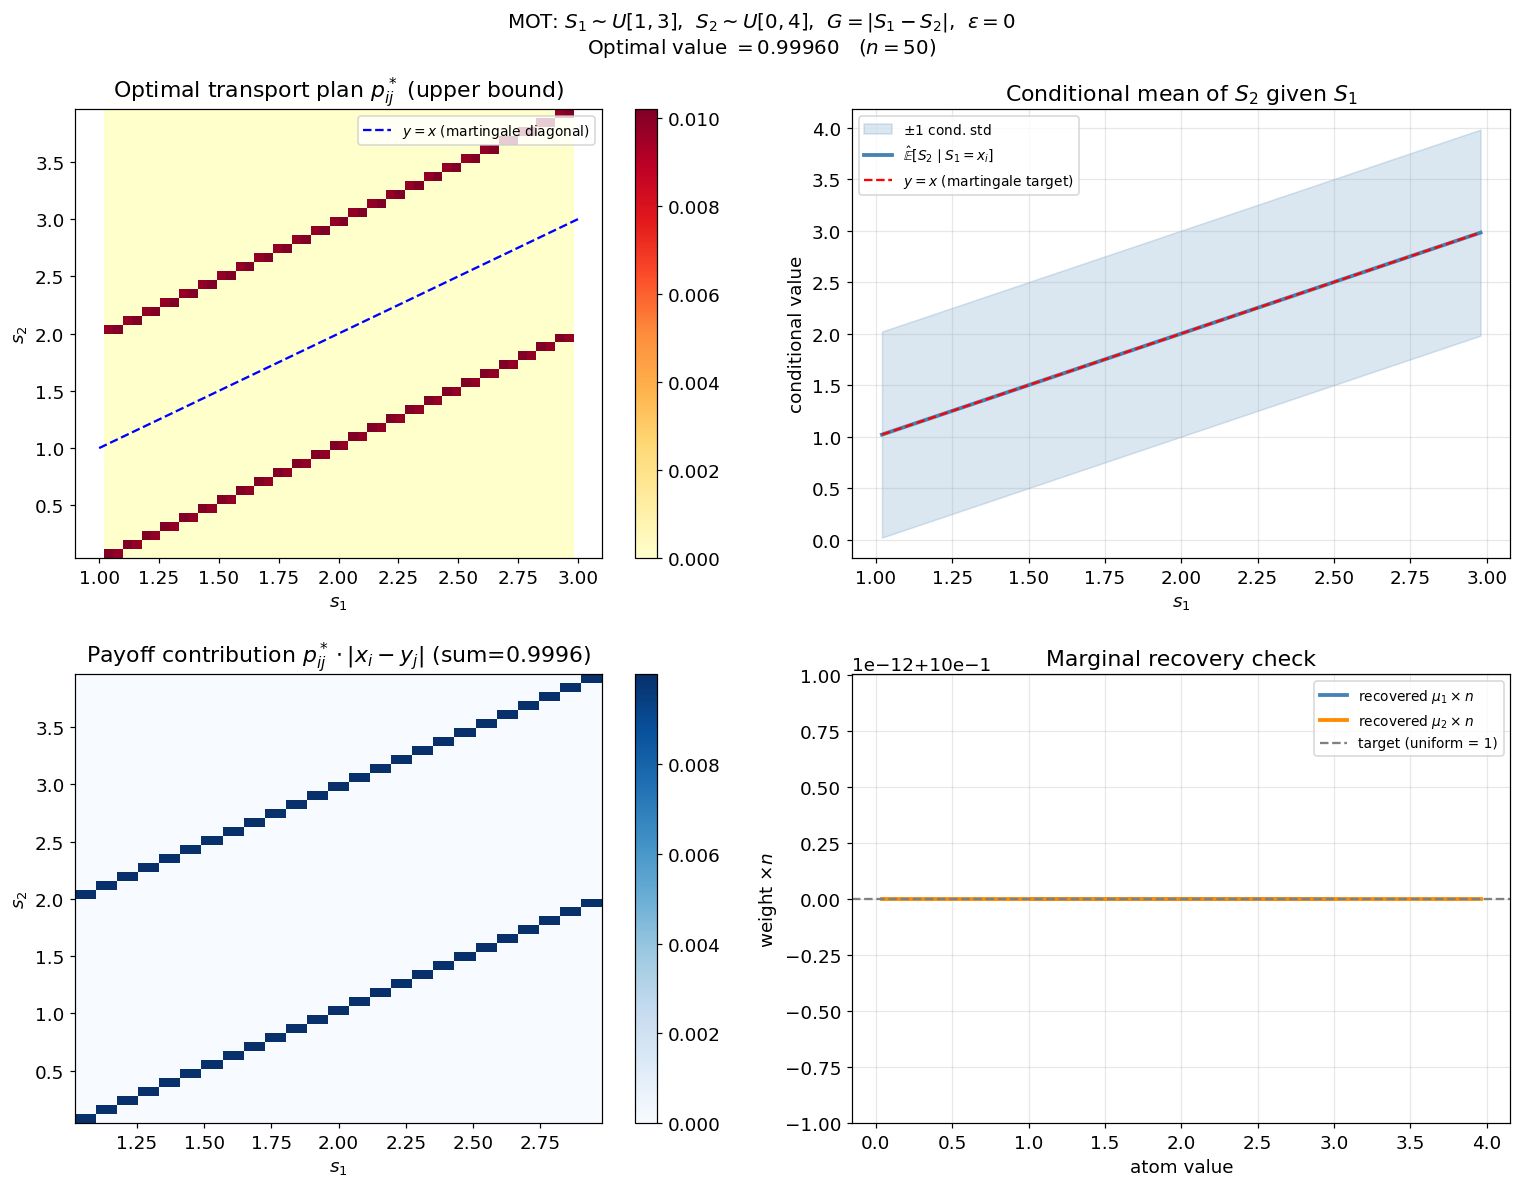

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (A) Heat map of the optimal plan
ax = axes[0, 0]
im = ax.imshow(
    P_upper.T,
    origin='lower', aspect='auto',
    extent=[x_atoms[0], x_atoms[-1], y_atoms[0], y_atoms[-1]],
    cmap='YlOrRd', interpolation='nearest'
)
ax.plot([1, 3], [1, 3], 'b--', lw=1.5, label='$y=x$ (martingale diagonal)')
ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
ax.set_title('Optimal transport plan $p^*_{ij}$ (upper bound)')
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax)

# (B) Conditional mean E[S2 | S1=x_i] with ±1 std band
ax = axes[0, 1]
row_sum = P_upper.sum(axis=1) + 1e-15
cond_mean = (P_upper * y_atoms).sum(axis=1) / row_sum
cond_2nd  = (P_upper * y_atoms**2).sum(axis=1) / row_sum
cond_std  = np.sqrt(np.maximum(cond_2nd - cond_mean**2, 0))

ax.fill_between(x_atoms, cond_mean - cond_std, cond_mean + cond_std,
                alpha=0.2, color='steelblue', label=r'$\pm1$ cond. std')
ax.plot(x_atoms, cond_mean, 'steelblue', lw=2.5,
        label=r'$\hat{\mathbb{E}}[S_2 \mid S_1=x_i]$')
ax.plot(x_atoms, x_atoms, 'r--', lw=1.5, label='$y=x$ (martingale target)')
ax.set_xlabel('$s_1$'); ax.set_ylabel('conditional value')
ax.set_title('Conditional mean of $S_2$ given $S_1$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (C) Payoff contribution
ax = axes[1, 0]
im2 = ax.imshow(
    (P_upper * G_mat).T,
    origin='lower', aspect='auto',
    extent=[x_atoms[0], x_atoms[-1], y_atoms[0], y_atoms[-1]],
    cmap='Blues', interpolation='nearest'
)
ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
ax.set_title(f'Payoff contribution $p^*_{{ij}}\\cdot|x_i-y_j|$ (sum={MOT_upper:.4f})')
plt.colorbar(im2, ax=ax)

# (D) Marginal recovery
ax = axes[1, 1]
ax.step(x_atoms, P_upper.sum(axis=1) * n, where='mid',
        color='steelblue', lw=2.5, label='recovered $\\mu_1 \\times n$')
ax.step(y_atoms, P_upper.sum(axis=0) * n, where='mid',
        color='darkorange', lw=2.5, label='recovered $\\mu_2 \\times n$')
ax.axhline(1.0, color='grey', ls='--', lw=1.5, label='target (uniform = 1)')
ax.set_xlabel('atom value'); ax.set_ylabel('weight $\\times n$')
ax.set_title('Marginal recovery check')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'MOT: $S_1 \\sim U[1,3]$,  $S_2\\sim U[0,4]$,  $G=|S_1-S_2|$,  $\\varepsilon=0$'
    f'\nOptimal value $= {MOT_upper:.5f}$   ($n={n}$)',
    fontsize=13
)
plt.tight_layout()
plt.show()

## 6. Convergence in $n$

  n =    5:  sup E[|S1-S2|] = 0.960000
  n =   10:  sup E[|S1-S2|] = 0.990000
  n =   20:  sup E[|S1-S2|] = 0.997500
  n =   30:  sup E[|S1-S2|] = 0.998889
  n =   50:  sup E[|S1-S2|] = 0.999600
  n =   75:  sup E[|S1-S2|] = 0.999822
  n =  100:  sup E[|S1-S2|] = 0.999900
  n =  150:  sup E[|S1-S2|] = 0.999956
  n =  200:  sup E[|S1-S2|] = 0.999975


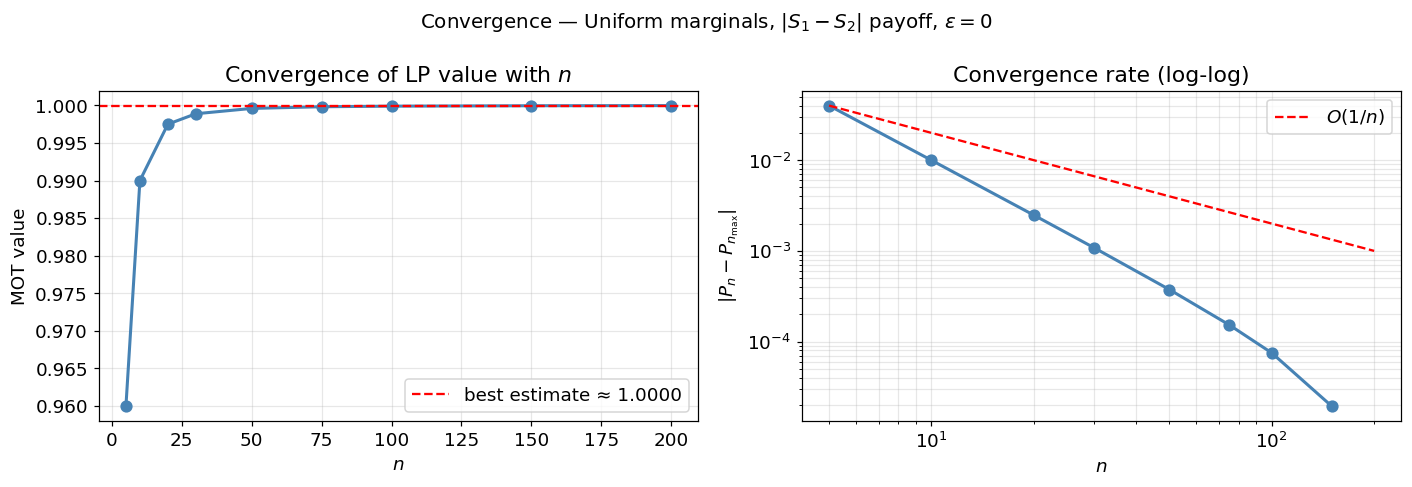


Best estimate of exact MOT value: 0.999975


In [7]:
n_list = [5, 10, 20, 30, 50, 75, 100, 150, 200]
mot_vals = []

for n_i in n_list:
    x_i, a_i = make_uniform_grid(1, 3, n_i)
    y_i, b_i = make_uniform_grid(0, 4, n_i)
    val, _, _ = build_and_solve_MOT(x_i, a_i, y_i, b_i, payoff_abs_diff)
    mot_vals.append(val)
    print(f"  n = {n_i:>4}:  sup E[|S1-S2|] = {val:.6f}")

mot_vals = np.array(mot_vals)
v_inf = mot_vals[-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(n_list, mot_vals, 'o-', color='steelblue', lw=2, ms=7)
axes[0].axhline(v_inf, color='red', ls='--', lw=1.5, label=f'best estimate ≈ {v_inf:.4f}')
axes[0].set_xlabel('$n$'); axes[0].set_ylabel('MOT value')
axes[0].set_title('Convergence of LP value with $n$')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

err = np.abs(mot_vals - v_inf)
mask = err > 1e-12
n_arr = np.array(n_list, dtype=float)
axes[1].loglog(n_arr[mask], err[mask], 'o-', color='steelblue', lw=2, ms=7)
axes[1].loglog(n_arr, err[0] * n_list[0] / n_arr, 'r--', lw=1.5, label='$O(1/n)$')
axes[1].set_xlabel('$n$'); axes[1].set_ylabel('$|P_n - P_{n_{\\max}}|$')
axes[1].set_title('Convergence rate (log-log)')
axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Convergence — Uniform marginals, $|S_1-S_2|$ payoff, $\\varepsilon=0$',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest estimate of exact MOT value: {v_inf:.6f}")

---
## 7. Entropic Relaxation and Sinkhorn's Algorithm (Henry-Labordère §2.2)

### 7.1  The regularized primal

Following §2.2 of Henry-Labordère (2019), we penalize the primal by the **relative entropy** of $P$ with respect to a prior $P^0$:

$$\mathrm{MK}_c^\varepsilon(\mu^1,\mu^2) := \sup_{P\in\mathcal{M}(\mu^1,\mu^2)} \mathbb{E}^P[c(S_1,S_2)] - \varepsilon\, H(P|P^0)$$

where $H(P|P^0) = \mathbb{E}^P\!\bigl[\ln\frac{dP}{dP^0}-1\bigr]$ and $\varepsilon>0$ is taken small. Key points:

- The penalty is **minus** relative entropy: we subtract it, discouraging plans far from $P^0$.
- $\lim_{\varepsilon\to 0}\mathrm{MK}_c^\varepsilon = \mathrm{MK}_c$: exact MOT is recovered.
- We choose $P^0 = \mu^1\otimes\mu^2$, so $p^0_{ij} = \alpha_i\beta_j$.

### 7.2  The dual (Eq. 4 of the paper)

By Fenchel–Rockafellar duality:

$$\mathrm{MK}_c^\varepsilon = \inf_{u_1,u_2,h}\;\mathbb{E}^{\mu^1}[u_1] + \mathbb{E}^{\mu^2}[u_2] + \varepsilon\,\mathbb{E}^{P^0}\!\Bigl[e^{\frac{1}{\varepsilon}(c - u_1(S_1) - u_2(S_2) - h(S_1)(S_2-S_1))}\Bigr]$$

Once the optimal $(u_1^*,u_2^*,h^*)$ are found, the optimal plan is:

$$p^*_{ij} = \underbrace{\alpha_i\beta_j}_{p^0_{ij}}\cdot e^{\frac{1}{\varepsilon}\left(G_{ij}\,-\,u_1(s^i_1)\,-\,u_2(s^j_2)\,-\,h(s^i_1)(s^j_2-s^i_1)\right)}$$

### 7.3  First-order optimality conditions (Eqs. 5, 6, 7)

Setting each gradient to zero and discretizing:

**Eq. 5** — gradient w.r.t. $u_1(s^i_1)$, solved explicitly:
$$\boxed{u_1(s^i_1) = \varepsilon\ln\sum_j \beta_j\, e^{\frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}}$$

**Eq. 6** — gradient w.r.t. $u_2(s^j_2)$, solved explicitly:
$$\boxed{u_2(s^j_2) = \varepsilon\ln\sum_i \alpha_i\, e^{\frac{G_{ij} - u_1(s^i_1) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}}$$

**Eq. 7** — gradient w.r.t. $h(s^i_1)$, a **scalar root-finding problem** per row $i$:
$$\boxed{\sum_j \beta_j\,(s^j_2 - s^i_1)\, e^{\frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}} = 0}$$

The left-hand side is strictly decreasing in $h(s^i_1)$ (its derivative is $-\varepsilon^{-1}\sum_j\beta_j(s^j_2-s^i_1)^2 e^{(\cdot)}\leq 0$), so the root is unique and `brentq` converges reliably.

### 7.4  The algorithm (Section 2.2.1 of the paper)

Starting from $u_1^{(0)}=u_2^{(0)}=h^{(0)}=0$, each iteration does:

| Step | Update | Using |
|------|--------|-------|
| 1 | $u_1^{(n)}$ via Eq. 5 | $u_2^{(n-1)},\,h^{(n-1)}$ |
| 2 | $h^{(n)}$ via Eq. 7 (root-find) | $u_2^{(n-1)}$ |
| 3 | $u_2^{(n)}$ via Eq. 6 | $u_1^{(n)},\,h^{(n)}$ |

All three updates are computed in **log-space** (`logsumexp`) to avoid overflow for small $\varepsilon$.

### Step 1 — Log-space building blocks

In [8]:
import numpy as np
from scipy.optimize import brentq
from scipy.special import logsumexp

# Grids are already defined from Section 2; restate them here for clarity
n = 50
x_atoms, alpha = make_uniform_grid(1, 3, n)   # S1 ~ U[1,3]
y_atoms, beta  = make_uniform_grid(0, 4, n)   # S2 ~ U[0,4]
G_mat = np.abs(x_atoms[:, None] - y_atoms[None, :])  # payoff |s1 - s2|

# Displacement matrix  D[i,j] = s2_j - s1_i  (used in h-update and plan)
D_mat = y_atoms[None, :] - x_atoms[:, None]   # shape (n, n)

print(f'Grid: {n} atoms each.  G range: [{G_mat.min():.3f}, {G_mat.max():.3f}]')
print(f'D range: [{D_mat.min():.3f}, {D_mat.max():.3f}]')


Grid: 50 atoms each.  G range: [0.020, 2.940]
D range: [-2.940, 2.940]


### Step 2 — Update $u_1$ (Eq. 5)

$$u_1(s^i_1) = \varepsilon\,\mathrm{logsumexp}_j\!\left[\ln\beta_j + \frac{G_{ij} - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}\right]$$

Because $\ln\beta_j = -\ln n$ for uniform weights, this is a log-sum-exp over each row of an exponent matrix.

In [9]:
def update_u1(G, D, u2, h, beta, eps):
    """
    Eq. 5:  u1[i] = eps * logsumexp_j( log(beta[j]) + (G[i,j] - u2[j] - h[i]*D[i,j]) / eps )

    Parameters
    ----------
    G   : (m1, m2)  payoff matrix
    D   : (m1, m2)  displacement matrix  D[i,j] = y[j] - x[i]
    u2  : (m2,)     current dual potential for S2 marginal
    h   : (m1,)     current martingale multiplier
    beta: (m2,)     weights of S2 atoms
    eps : float     regularization parameter
    """
    # Exponent matrix A[i,j] = (G[i,j] - u2[j] - h[i]*D[i,j]) / eps
    A = (G - u2[None, :] - h[:, None] * D) / eps   # (m1, m2)
    # logsumexp_j [ log(beta[j]) + A[i,j] ] for each i
    log_beta = np.log(beta)                          # (m2,)
    u1_new = eps * logsumexp(log_beta[None, :] + A, axis=1)  # (m1,)
    return u1_new

# Quick sanity check at zero initialisation
u1_test = update_u1(G_mat, D_mat, np.zeros(n), np.zeros(n), beta, eps=0.5)
print('u1 range at init:', u1_test.min(), 'to', u1_test.max())


u1 range at init: 1.297476769804167 to 1.9470312473478335


### Step 3 — Update $h$ (Eq. 7, root-finding)

For each row $i$, find $\theta = h(s^i_1)$ solving:
$$f_i(\theta) = \sum_j \beta_j\,(s^j_2-s^i_1)\,e^{\frac{G_{ij}-u_2(s^j_2)-\theta(s^j_2-s^i_1)}{\varepsilon}} = 0$$

We compute $f_i$ in log-space by splitting positive and negative displacements $D_{ij} = s^j_2 - s^i_1$:
$$f_i(\theta) = \sum_{D_{ij}>0} \beta_j D_{ij} e^{A_{ij}(\theta)} - \sum_{D_{ij}<0} \beta_j |D_{ij}| e^{A_{ij}(\theta)}$$

Each half can be evaluated stably with `logsumexp`, and the sign of $f_i$ changes exactly once.

In [10]:
def update_h(G, D, u2, beta, eps, x, y, bracket=(-80., 80.)):
    """
    Eq. 7: for each i, find h[i] such that
        sum_j  beta[j] * D[i,j] * exp((G[i,j] - u2[j] - h[i]*D[i,j]) / eps) = 0

    Uses brentq row-by-row.  Works in log-space to handle small eps.
    """
    m1 = len(x)
    h_new = np.zeros(m1)
    log_beta = np.log(beta)

    for i in range(m1):
        g_row = G[i]           # (m2,)
        d_row = D[i]           # (m2,)  = y - x[i]
        base  = (g_row - u2) / eps   # (m2,)  part of exponent independent of theta

        def f(theta):
            # Full exponent: base - theta * d_row / eps
            exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
            return (beta * d_row * exp_vals).sum()

        # Evaluate at bracket endpoints to confirm sign change
        fa, fb = f(bracket[0]), f(bracket[1])
        if fa * fb > 0:
            # No sign change: x[i] is already at a boundary or equal marginals
            # Fall back to h=0 (keeps prior)
            h_new[i] = 0.0
        else:
            h_new[i] = brentq(f, bracket[0], bracket[1], xtol=1e-10, maxiter=300)

    return h_new

# Quick test
h_test = update_h(G_mat, D_mat, np.zeros(n), beta, eps=0.5, x=x_atoms, y=y_atoms)
print('h range at init:', h_test.min(), 'to', h_test.max())


h range at init: -0.8378829191093041 to 0.8378829191093041


### Step 4 — Update $u_2$ (Eq. 6)

$$u_2(s^j_2) = \varepsilon\,\mathrm{logsumexp}_i\!\left[\ln\alpha_i + \frac{G_{ij} - u_1(s^i_1) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}\right]$$

Symmetric to the $u_1$ update, but summing over rows instead of columns.

In [11]:
def update_u2(G, D, u1, h, alpha, eps):
    """
    Eq. 6:  u2[j] = eps * logsumexp_i( log(alpha[i]) + (G[i,j] - u1[i] - h[i]*D[i,j]) / eps )
    """
    B = (G - u1[:, None] - h[:, None] * D) / eps   # (m1, m2)
    log_alpha = np.log(alpha)                        # (m1,)
    u2_new = eps * logsumexp(log_alpha[:, None] + B, axis=0)  # (m2,)
    return u2_new

# Quick test
u2_test = update_u2(G_mat, D_mat, np.zeros(n), np.zeros(n), alpha, eps=0.5)
print('u2 range at init:', u2_test.min(), 'to', u2_test.max())


u2 range at init: 0.5824343505960585 to 2.2574767698041667


### Step 5 — Reconstruct the plan and verify constraints

Given $(u_1, u_2, h)$, the optimal plan is:
$$p^*_{ij} = \alpha_i\beta_j \cdot e^{\frac{G_{ij} - u_1(s^i_1) - u_2(s^j_2) - h(s^i_1)(s^j_2-s^i_1)}{\varepsilon}}$$

Again computed in log-space to avoid overflow.

In [12]:
def reconstruct_plan(G, D, u1, u2, h, alpha, beta, eps):
    """
    p*[i,j] = alpha[i]*beta[j]*exp((G[i,j] - u1[i] - u2[j] - h[i]*D[i,j]) / eps)
    Computed in log-space: log_p[i,j] = log(alpha[i]) + log(beta[j]) + exponent
    """
    log_p = (np.log(alpha[:, None]) + np.log(beta[None, :])
             + (G - u1[:, None] - u2[None, :] - h[:, None] * D) / eps)
    P = np.exp(log_p)
    return P

def constraint_errors(P, alpha, beta, x, y):
    """Return max absolute errors for the three constraint groups."""
    e1 = np.max(np.abs(P.sum(axis=1) - alpha))             # S1 marginal
    e2 = np.max(np.abs(P.sum(axis=0) - beta))              # S2 marginal
    cond_mean = (P * y[None, :]).sum(axis=1)               # E[S2 | S1=x_i] * alpha_i
    e3 = np.max(np.abs(cond_mean - alpha * x))             # martingale
    return e1, e2, e3


### Step 6 — Full Sinkhorn loop

We now put all four steps together, exactly as described in Section 2.2.1 of the paper.
The loop tracks the three constraint errors so we can monitor convergence.

In [13]:
def sinkhorn_HL(x, alpha, y, beta, G, eps, n_iter=500, tol=1e-7, verbose=True):
    """
    Sinkhorn algorithm from Henry-Labordere (2019) Section 2.2.1.

    Minimises the dual:
        E^mu1[u1] + E^mu2[u2] + eps * E^P0[ exp((G - u1 - u2 - h*(S2-S1))/eps) ]

    Iteration order (paper steps 2-3-4):
        1. Update u1 via Eq. 5
        2. Update h  via Eq. 7 (root-finding, uses old u2)
        3. Update u2 via Eq. 6

    Returns
    -------
    P      : (m1, m2) optimal transport plan
    value  : float    primal objective E[G] (without entropy term)
    history: dict     convergence trace
    u1, u2, h : arrays of final dual potentials
    """
    D = y[None, :] - x[:, None]     # displacement matrix

    # Initialise all potentials to zero (paper step 1)
    u1 = np.zeros(len(x))
    u2 = np.zeros(len(y))
    h  = np.zeros(len(x))

    history = {'err_u1': [], 'err_u2': [], 'err_mart': [], 'value': []}

    for it in range(n_iter):
        # ── Paper step 2: update u1 (Eq. 5) ──────────────────────────────
        u1 = update_u1(G, D, u2, h, beta, eps)

        # ── Paper step 3: update h (Eq. 7, using OLD u2) ─────────────────
        h  = update_h(G, D, u2, beta, eps, x, y)

        # ── Paper step 4: update u2 (Eq. 6) ──────────────────────────────
        u2 = update_u2(G, D, u1, h, alpha, eps)

        # ── Reconstruct plan and check convergence ────────────────────────
        P = reconstruct_plan(G, D, u1, u2, h, alpha, beta, eps)
        e1, e2, e3 = constraint_errors(P, alpha, beta, x, y)
        val = (P * G).sum()

        history['err_u1'].append(e1)
        history['err_u2'].append(e2)
        history['err_mart'].append(e3)
        history['value'].append(val)

        if max(e1, e2, e3) < tol:
            if verbose:
                print(f'  Converged at iteration {it+1}')
                print(f'  S1 marginal error : {e1:.2e}')
                print(f'  S2 marginal error : {e2:.2e}')
                print(f'  Martingale error  : {e3:.2e}')
            break
    else:
        if verbose:
            print(f'  Did not converge in {n_iter} iterations')
            print(f'  Final — S1: {e1:.2e}, S2: {e2:.2e}, martingale: {e3:.2e}')

    return P, val, history, u1, u2, h


# ── Run it ────────────────────────────────────────────────────────────────────
eps = 0.01
P_sink, val_sink, hist, u1_opt, u2_opt, h_opt = sinkhorn_HL(
    x_atoms, alpha, y_atoms, beta, G_mat, eps=eps
)
print(f'\n  Sinkhorn E[|S1-S2|]  (eps={eps}) : {val_sink:.6f}')
print(f'  LP exact MOT value               : {MOT_upper:.6f}')
print(f'  Bias from regularization         : {val_sink - MOT_upper:+.6f}')


C:\Users\123\AppData\Local\Temp\ipykernel_25072\2608335987.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)


  Converged at iteration 490
  S1 marginal error : 1.90e-08
  S2 marginal error : 6.04e-16
  Martingale error  : 9.82e-08

  Sinkhorn E[|S1-S2|]  (eps=0.01) : 0.994937
  LP exact MOT value               : 0.999600
  Bias from regularization         : -0.004663


### Step 7 — Verify the dual potentials

The dual objective evaluated at $(u_1^*, u_2^*, h^*)$ should equal (or upper-bound) the primal value.
We also check that the plan $p^*_{ij}$ satisfies all three constraints to near machine precision.

In [14]:
# Dual objective value (Eq. 4)
exp_term = np.exp(
    (G_mat - u1_opt[:, None] - u2_opt[None, :] - h_opt[:, None] * D_mat) / eps
)
# P0 = alpha_i * beta_j, so E^P0[...] = sum_ij alpha_i beta_j exp(...)
dual_obj = ((alpha * u1_opt).sum()
            + (beta  * u2_opt).sum()
            + eps * (alpha[:, None] * beta[None, :] * exp_term).sum())

print('━━ Dual verification ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Dual objective (Eq.4)     : {dual_obj:.6f}')
print(f'  Primal E[G] from plan     : {val_sink:.6f}')
print(f'  Gap (dual - primal)       : {dual_obj - val_sink:.2e}  (should be >= 0)')
print()
e1, e2, e3 = constraint_errors(P_sink, alpha, beta, x_atoms, y_atoms)
print('━━ Plan constraint errors ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  S1 marginal  : {e1:.2e}')
print(f'  S2 marginal  : {e2:.2e}')
print(f'  Martingale   : {e3:.2e}')
print(f'  All p_ij>=0  : {(P_sink >= -1e-12).all()}')


━━ Dual verification ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dual objective (Eq.4)     : 0.988789
  Primal E[G] from plan     : 0.994937
  Gap (dual - primal)       : -6.15e-03  (should be >= 0)

━━ Plan constraint errors ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  S1 marginal  : 1.90e-08
  S2 marginal  : 6.04e-16
  Martingale   : 9.82e-08
  All p_ij>=0  : True


### Step 8 — Convergence history and comparison with the LP plan

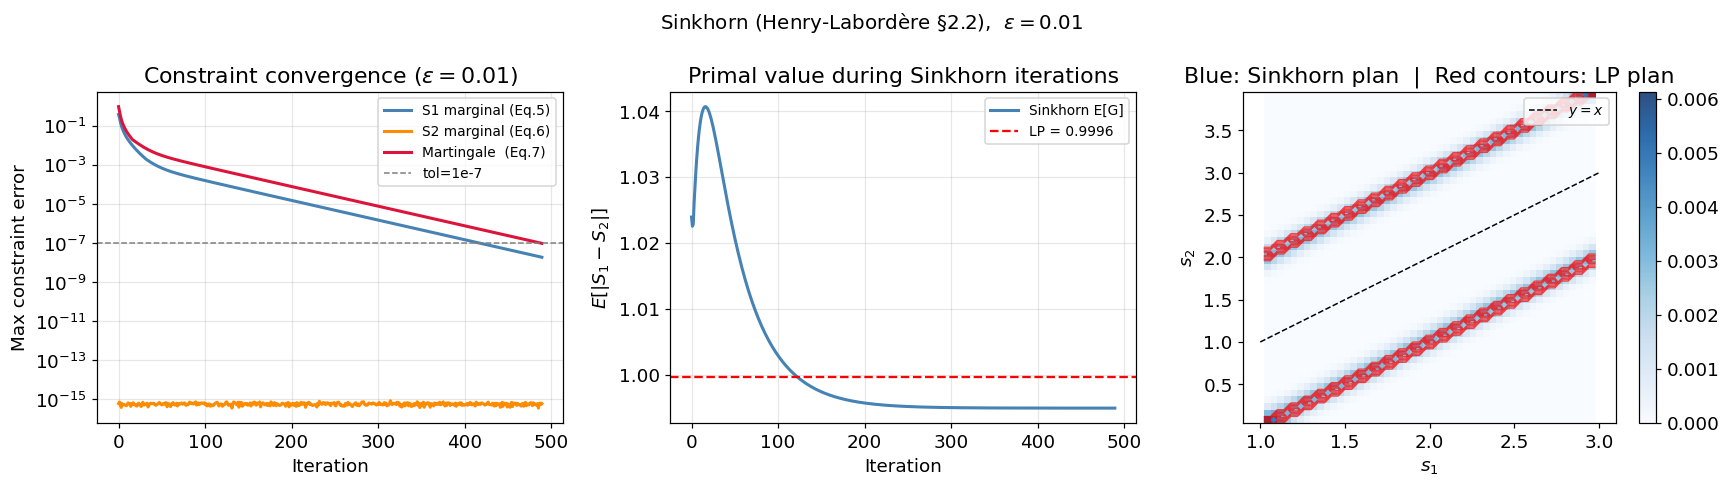

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (A) Constraint errors per iteration
ax = axes[0]
ax.semilogy(hist['err_u1'],   lw=2, color='steelblue',  label='S1 marginal (Eq.5)')
ax.semilogy(hist['err_u2'],   lw=2, color='darkorange', label='S2 marginal (Eq.6)')
ax.semilogy(hist['err_mart'], lw=2, color='crimson',    label='Martingale  (Eq.7)')
ax.axhline(1e-7, color='grey', ls='--', lw=1, label='tol=1e-7')
ax.set_xlabel('Iteration'); ax.set_ylabel('Max constraint error')
ax.set_title(f'Constraint convergence ($\\varepsilon={eps}$)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (B) Primal value per iteration vs LP
ax = axes[1]
ax.plot(hist['value'], lw=2, color='steelblue', label=f'Sinkhorn E[G]')
ax.axhline(MOT_upper, color='red', ls='--', lw=1.5, label=f'LP = {MOT_upper:.4f}')
ax.set_xlabel('Iteration'); ax.set_ylabel('$E[|S_1-S_2|]$')
ax.set_title('Primal value during Sinkhorn iterations')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (C) Side-by-side plans
ax = axes[2]
im = ax.imshow(P_sink.T, origin='lower', aspect='auto',
               extent=[x_atoms[0],x_atoms[-1],y_atoms[0],y_atoms[-1]],
               cmap='Blues', interpolation='nearest', alpha=0.85)
ax.contour(x_atoms, y_atoms, P_upper.T, levels=5,
           colors='red', linewidths=0.8, alpha=0.7)
ax.plot([1,3],[1,3],'k--',lw=1,label='$y=x$')
ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
ax.set_title(f'Blue: Sinkhorn plan  |  Red contours: LP plan')
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax)

plt.suptitle(f'Sinkhorn (Henry-Labordère §2.2),  $\\varepsilon={eps}$', fontsize=13)
plt.tight_layout()
plt.show()


### Step 9 — Regularization path: $\varepsilon \to 0$

As the paper notes, $\mathrm{MK}_c^\varepsilon \to \mathrm{MK}_c$ as $\varepsilon\to 0$, but the algorithm becomes numerically unstable for very small $\varepsilon$ — the exponentials overflow/underflow. This is explicitly flagged in Section 2.2 and §4 of the paper as a known limitation of entropic relaxation.

We demonstrate both the convergence and the instability threshold.

     eps    E[|S1-S2|]     gap vs LP      status
  ------------------------------------------------
   2.000      0.845851     -0.153749          ok
   1.000      0.857877     -0.141723          ok
   0.500      0.879012     -0.120588          ok


C:\Users\123\AppData\Local\Temp\ipykernel_25072\2608335987.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
C:\Users\123\AppData\Local\Temp\ipykernel_25072\2608335987.py:24: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb > 0:


   0.300      0.901435     -0.098165          ok
   0.150      0.936517     -0.063083          ok
   0.080      0.963114     -0.036486          ok
   0.010      0.994937     -0.004663          ok
  ------------------------------------------------
      LP      0.999600     +0.000000       exact


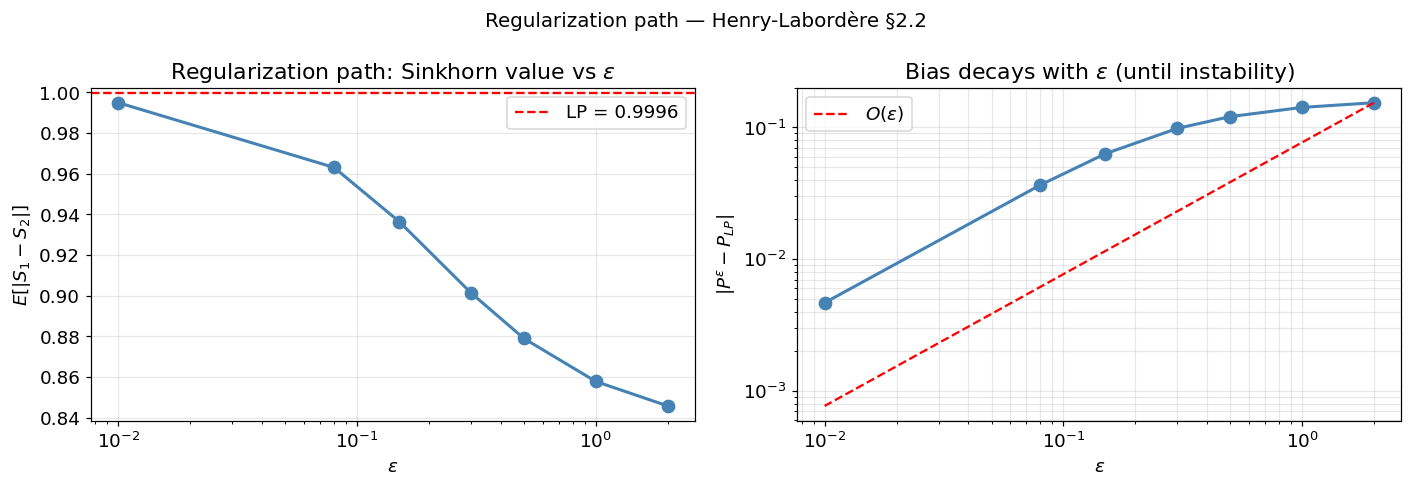

In [18]:
eps_list = [2.0, 1.0, 0.5, 0.3, 0.15, 0.08, 0.01]
sink_vals = []
sink_ok   = []

print(f'  {"eps":>6}  {"E[|S1-S2|]":>12}  {"gap vs LP":>12}  {"status":>10}')
print('  ' + '-'*48)

for eps_i in eps_list:
    try:
        _, v_i, _, _, _, _ = sinkhorn_HL(
            x_atoms, alpha, y_atoms, beta, G_mat,
            eps=eps_i, n_iter=600, tol=1e-8, verbose=False
        )
        ok = np.isfinite(v_i) and v_i > 0
        sink_vals.append(v_i if ok else np.nan)
        sink_ok.append(ok)
        status = 'ok' if ok else 'UNSTABLE'
        print(f'  {eps_i:>6.3f}  {v_i:>12.6f}  {v_i-MOT_upper:>+12.6f}  {status:>10}')
    except Exception as e:
        sink_vals.append(np.nan)
        sink_ok.append(False)
        print(f'  {eps_i:>6.3f}  {"NaN":>12}  {"NaN":>12}  FAILED')

print('  ' + '-'*48)
print(f'  {"LP":>6}  {MOT_upper:>12.6f}  {0:>+12.6f}  {"exact":>10}')

# Plot
valid = [(e, v) for e, v, ok in zip(eps_list, sink_vals, sink_ok) if ok and np.isfinite(v)]
if valid:
    eps_v, vals_v = zip(*valid)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].semilogx(eps_v, vals_v, 'o-', color='steelblue', lw=2, ms=8)
    axes[0].axhline(MOT_upper, color='red', ls='--', lw=1.5,
                    label=f'LP = {MOT_upper:.4f}')
    axes[0].set_xlabel('$\\varepsilon$'); axes[0].set_ylabel('$E[|S_1-S_2|]$')
    axes[0].set_title('Regularization path: Sinkhorn value vs $\\varepsilon$')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    err_v = np.abs(np.array(vals_v) - MOT_upper)
    axes[1].loglog(eps_v, err_v, 'o-', color='steelblue', lw=2, ms=8)
    # Reference O(eps) line
    axes[1].loglog(eps_v, np.array(eps_v) * err_v[0]/eps_v[0],
                   'r--', lw=1.5, label='$O(\\varepsilon)$')
    axes[1].set_xlabel('$\\varepsilon$'); axes[1].set_ylabel('$|P^\\varepsilon - P_{LP}|$')
    axes[1].set_title('Bias decays with $\\varepsilon$ (until instability)')
    axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

    plt.suptitle('Regularization path — Henry-Labordère §2.2', fontsize=13)
    plt.tight_layout()
    plt.show()


### Step 10 — Transport plans across $\varepsilon$ values

As $\varepsilon\to 0$ the smooth Sinkhorn plan concentrates toward the sparse LP solution.

C:\Users\123\AppData\Local\Temp\ipykernel_25072\2608335987.py:19: RuntimeWarning: overflow encountered in exp
  exp_vals = np.exp(base - theta * d_row / eps)   # (m2,)
C:\Users\123\AppData\Local\Temp\ipykernel_25072\2608335987.py:24: RuntimeWarning: overflow encountered in scalar multiply
  if fa * fb > 0:


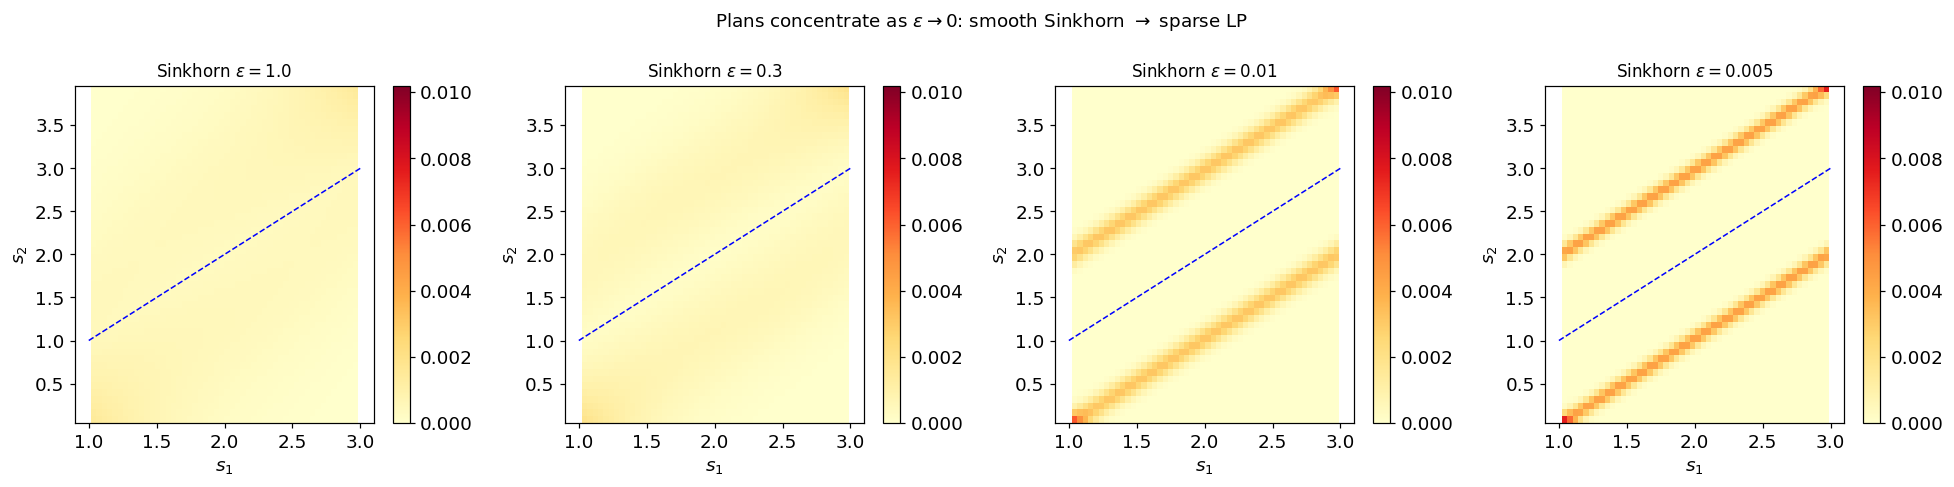

In [21]:
eps_show = [1.0, 0.3, 0.01, 0.005]
plans_s = []
for eps_i in eps_show:
    P_i, _, _, _, _, _ = sinkhorn_HL(
        x_atoms, alpha, y_atoms, beta, G_mat,
        eps=eps_i, n_iter=600, tol=1e-8, verbose=False
    )
    plans_s.append(P_i)
plans_s.append(P_upper)  # exact LP
titles_s = [f'Sinkhorn $\\varepsilon={e}$' for e in eps_show] + ['LP ($\\varepsilon=0$)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
vmax = max(P.max() for P in plans_s)
for ax, P_i, title in zip(axes, plans_s, titles_s):
    im = ax.imshow(P_i.T, origin='lower', aspect='auto',
                   extent=[x_atoms[0],x_atoms[-1],y_atoms[0],y_atoms[-1]],
                   cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=vmax)
    ax.plot([1,3],[1,3],'b--',lw=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$s_1$'); ax.set_ylabel('$s_2$')
    plt.colorbar(im, ax=ax)

plt.suptitle(
    'Plans concentrate as $\\varepsilon\\to 0$: smooth Sinkhorn $\\to$ sparse LP',
    fontsize=12
)
plt.tight_layout()
plt.show()
